## 📊 Exploratory Data Analysis (EDA)

### 🎯 Objective
To explore patterns, relationships, and trends in the dataset, and identify key factors influencing customer churn.

### 🧠 Why EDA Matters
EDA helps uncover hidden insights, detect anomalies, and guide deeper analysis.

In [162]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from src.utils import load_data
import sys, os
sys.path.append(os.path.abspath(".."))
sns.set(style="whitegrid")

### 📂 Load Cleaned Dataset

In [163]:
df = pd.read_csv("/Users/hp/Documents/ASTU/CSEC_Projects/DataScience/telco-churn-analysis/data/raw/cleaned_telco.csv")
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,Churn_numeric,AvgMonthlySpend
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,no,0,29.850000
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,No,No,One year,No,Mailed check,56.95,1889.50,no,0,55.573529
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,yes,1,54.075000
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,no,0,40.905556
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,yes,1,75.825000


In [164]:
# Ensure correct format
df['Churn'] = df['Churn']
# df['Churn_numeric'] = df['Churn'].astype(int)
# Clean first
df['Churn'] = df['Churn'].astype(str).str.strip().str.lower()
# Convert to numeric
df['Churn'] = df['Churn'].map({'yes': 1, 'no': 0})
print(df["Churn"])


0       0
1       0
2       1
3       0
4       1
       ..
7027    0
7028    0
7029    0
7030    1
7031    0
Name: Churn, Length: 7032, dtype: int64


### 📊 Churn Distribution

Understanding the proportion of customers who churned vs stayed.

In [165]:
print(df[['Churn', 'Churn_numeric']].head())
df[['Churn', 'Churn_numeric']].head()

   Churn  Churn_numeric
0      0              0
1      0              0
2      1              1
3      0              0
4      1              1


,Churn,Churn_numeric
0,0,0
1,0,0
2,1,1
3,0,0
4,1,1


Bar chart which shows churn distribution

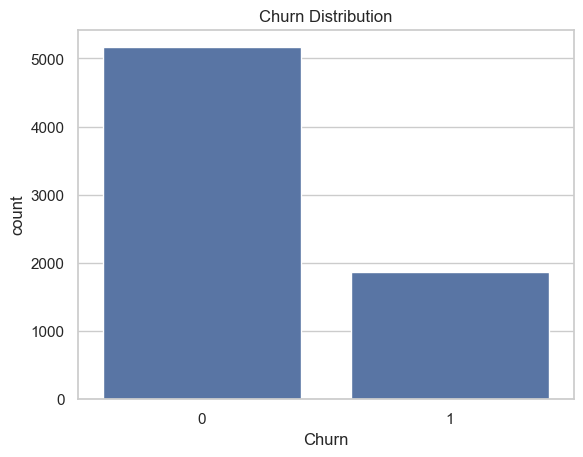

In [166]:
sns.countplot(x='Churn', data=df)
plt.title("Churn Distribution")
plt.savefig("../outputs/figures/Churn Distribution.png")
plt.show()

### ⏱️ Tenure vs Churn

Analyzing how long customers stay before churning.

In [167]:
df['Churn'].value_counts()

Churn
0    5163
1    1869
Name: count, dtype: int64

#### Tenure vs Churn - Boxplot
Compare tenure distribution between churned and non-churned customers

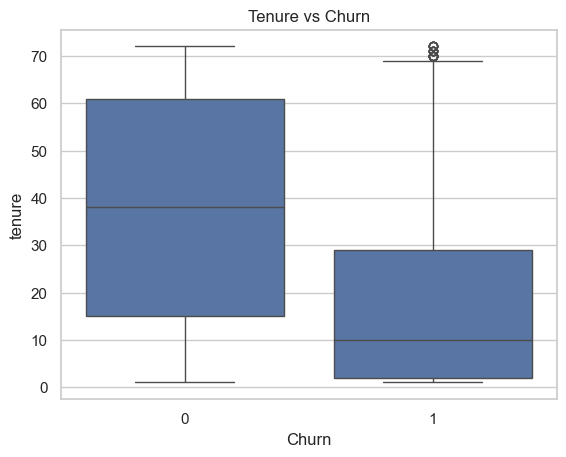

In [168]:
sns.boxplot(x='Churn', y='tenure',  data=df)
plt.title("Tenure vs Churn")
plt.savefig("../outputs/figures/tenure_vs_churn.png")
plt.show()

In [169]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7032 entries, 0 to 7031
Data columns (total 23 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7032 non-null   object 
 1   gender            7032 non-null   object 
 2   SeniorCitizen     7032 non-null   int64  
 3   Partner           7032 non-null   object 
 4   Dependents        7032 non-null   object 
 5   tenure            7032 non-null   int64  
 6   PhoneService      7032 non-null   object 
 7   MultipleLines     7032 non-null   object 
 8   InternetService   7032 non-null   object 
 9   OnlineSecurity    7032 non-null   object 
 10  OnlineBackup      7032 non-null   object 
 11  DeviceProtection  7032 non-null   object 
 12  TechSupport       7032 non-null   object 
 13  StreamingTV       7032 non-null   object 
 14  StreamingMovies   7032 non-null   object 
 15  Contract          7032 non-null   object 
 16  PaperlessBilling  7032 non-null   object 


In [170]:
df['tenure'] = pd.to_numeric(df['tenure'], errors='coerce')
df['Churn_numeric'] = pd.to_numeric(df['Churn'], errors='coerce')

In [171]:
print(f"DataFrame shape: {df.shape}")
print(f"Number of rows: {len(df)}")
print(f"Number of columns: {len(df.columns)}")

DataFrame shape: (7032, 23)
Number of rows: 7032
Number of columns: 23


In [172]:
df = df.dropna(subset=['tenure', 'Churn'])

In [173]:
print(df['Churn'].unique())

[0 1]


### 📊 Churn Rate by Contract Type

Analyzing churn percentage means Calculating churn percentage for each contract type.

In [174]:
contract_churn = pd.crosstab(df['Contract'], df['Churn'], normalize='index') * 100
contract_churn

Churn,0,1
Contract,,
Month-to-month,57.290323,42.709677
One year,88.722826,11.277174
Two year,97.151335,2.848665


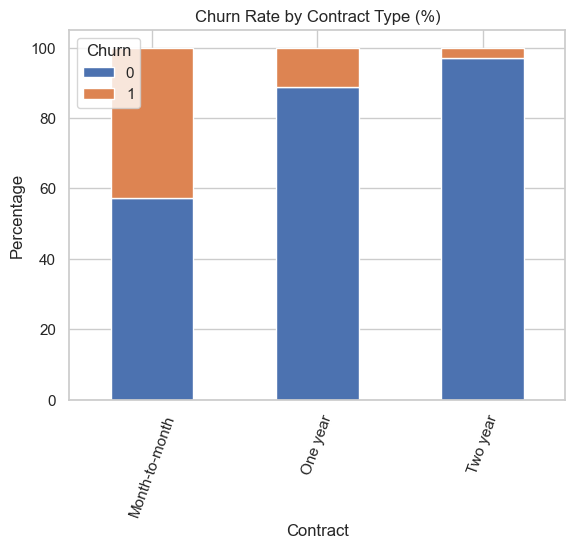

In [175]:
contract_churn.plot(kind="bar", stacked=True)
plt.title("Churn Rate by Contract Type (%)")
plt.ylabel("Percentage")
plt.xticks(rotation=70)
plt.savefig("../outputs/figures/churn Rate by Contract Type (%).png")
plt.show()

As we see from the graph Month-to-month contracts show significantly higher churn rates compared to long-term (One year and Two year) contracts, indicating that customer commitment plays a critical role in retention.

### 💳 Churn Rate by Payment Method

In [186]:
payment_churn = pd.crosstab(df['PaymentMethod'], df['Churn'], normalize='index') * 100
payment_churn

Churn,0,1
PaymentMethod,,
Bank transfer (automatic),83.268482,16.731518
Credit card (automatic),84.746877,15.253123
Electronic check,54.714588,45.285412
Mailed check,80.798005,19.201995


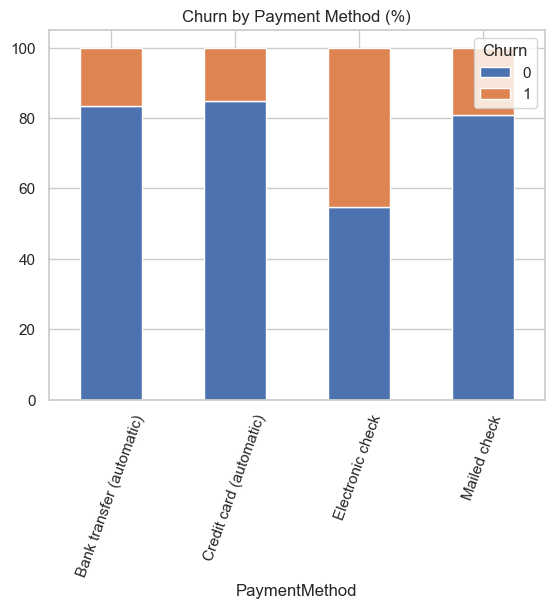

In [177]:
payment_churn.plot(kind='bar', stacked=True)
plt.title("Churn by Payment Method (%)")
plt.xticks(rotation=70)
plt.savefig("../outputs/figures/Churn by Payment Method (%).png")
plt.show()

We can see that a customers using electronic check have the highest churn rate, suggesting possible friction in payment experience or lower engagement.

### 🧠 Multi-Dimensional Analysis: Contract + Tenure + Churn

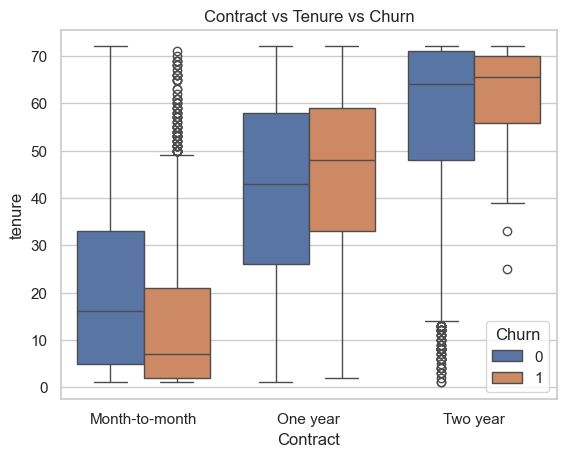

In [178]:
sns.boxplot(x='Contract', y='tenure', hue='Churn', data=df)
plt.title("Contract vs Tenure vs Churn")
plt.savefig("../outputs/figures/Contract vs Tenure vs Churn.png")
plt.show()

Even at similar tenure levels, customers on month-to-month contracts churn significantly more, indicating that contract type influences churn beyond just customer lifetime.

** So we call this " selection-level thinking" **

### 👥 Customer Segmentation by Tenure

In [179]:
df['TenureGroup'] = pd.cut(df['tenure'], bins=[0,12,24,48,72], 
                          labels=['0-12','12-24','24-48','48-72'])

Tenure Cohort Churn Rates

In [180]:
tenure_churn = pd.crosstab(df['TenureGroup'], df['Churn'], normalize='index') * 100
tenure_churn

Churn,0,1
TenureGroup,,
0-12,52.321839,47.678161
12-24,71.289062,28.710938
24-48,79.611041,20.388959
48-72,90.486824,9.513176


Customers in their first 12 months exhibit the highest churn rates, highlighting the importance of early customer engagement and onboarding strategies.

This shows that the early stage of the customer relationship is critical, and strong onboarding or engagement strategies can greatly reduce churn risk.

### 🚨 Outlier Analysis: High Spending Customers

In [181]:
df['TotalCharges'].describe()

count    7032.000000
mean     2283.300441
std      2266.771362
min        18.800000
25%       401.450000
50%      1397.475000
75%      3794.737500
max      8684.800000
Name: TotalCharges, dtype: float64

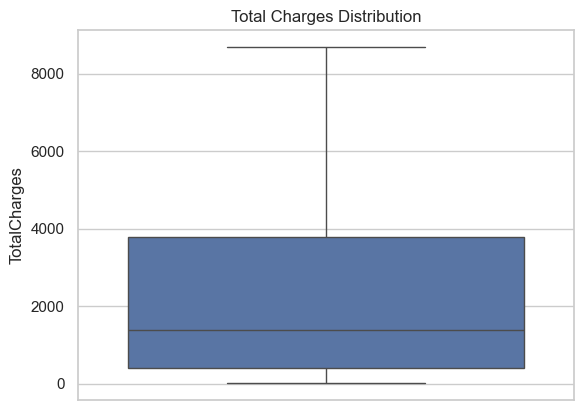

In [182]:
sns.boxplot(y=df['TotalCharges'])
plt.title("Total Charges Distribution")
plt.savefig("../outputs/figures/Total Charges Distribution.png")
plt.show()

This graph shows us a small group of customers contributes disproportionately high total charges, suggesting the presence of high-value customers who may require targeted retention strategies.

### 🔗 Correlation with Churn

In [183]:
corr = df.corr(numeric_only=True)
corr['Churn_numeric'].sort_values(ascending=False)

Churn              1.000000
Churn_numeric      1.000000
MonthlyCharges     0.192858
AvgMonthlySpend    0.192033
SeniorCitizen      0.150541
TotalCharges      -0.199484
tenure            -0.354049
Name: Churn_numeric, dtype: float64

While tenure and churn are negatively correlated (r = -0.35), this doesn't prove longer tenure causes loyalty — it could reflect that loyal customers simply stay longer. However, cohort analysis controlling for contract type suggests a genuine retention effect.

There is a negative correlation between tenure and churn, indicating that customers who stay longer are less likely to churn.

Generally correlation analysis revealed both positive and negative relationships, where negative correlations indicate factors that reduce churn likelihood, such as customer tenure.

### 🔗 Covariance Analysis

Covariance measures how two variables change together. Unlike correlation, it is not standardized and depends on the scale of variables.

In [191]:
cov_matrix = df.cov(numeric_only=True)
cov_matrix

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn,Churn_numeric,AvgMonthlySpend
SeniorCitizen,0.136046,0.141988,2.439951,8.562397e+01,0.024530,0.024530,2.422915
tenure,0.141988,602.469774,182.299526,4.595074e+04,-3.839186,-3.839186,182.413330
MonthlyCharges,2.439951,182.299526,905.165825,4.440133e+04,2.563362,2.563362,904.754746
TotalCharges,85.623972,45950.743236,44401.333073,5.138252e+06,-199.766978,-199.766978,44538.567937
Churn,0.024530,-3.839186,2.563362,-1.997670e+02,0.195171,0.195171,2.560865
Churn_numeric,0.024530,-3.839186,2.563362,-1.997670e+02,0.195171,0.195171,2.560865
AvgMonthlySpend,2.422915,182.413330,904.754746,4.453857e+04,2.560865,2.560865,911.187986


Covariance indicates the direction of relationships between variables, but due to its dependence on scale, correlation is more suitable for interpreting strength and comparing relationships.

While covariance confirms the direction of relationships observed in correlation, correlation is preferred for analysis due to its standardized nature.